I needed to use cuda for part 4 because it was taking hours on my laptop, so hopefully there is no compatibility issues

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time
import multiprocessing
# AMP (automatic mixed precision) helpers
from torch.cuda.amp import autocast, GradScaler

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
class VGG13(nn.Module):
    
    def __init__(self, num_classes=36, dropout=0.5):
        super(VGG13, self).__init__()
        
        # Convolutional layers (feature extraction)
        self.features = nn.Sequential(
            # Block 1: 64 filters (28x28 -> 14x14)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28x28 -> 14x14
            
            # Block 2: 128 filters (14x14 -> 7x7)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14x14 -> 7x7
            
            # Block 3: 256 filters (keep 7x7, no pooling)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Skip MaxPool to maintain spatial dimensions
            
            # Block 4: 512 filters (7x7 -> 3x3)
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 7x7 -> 3x3
            
            # Block 5: 512 filters (keep 3x3)
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Skip MaxPool to avoid too small dimensions
        )
        
        # Adaptive pooling to handle varying input sizes
        self.avgpool = nn.AdaptiveAvgPool2d((3, 3))
        
        # Classifier (fully connected layers)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, num_classes)
        )
        
        # Initialize weights
        self._initialize_weights()
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [4]:
import torch

# Device selection — prefer CUDA when available
#Got this from stack overflow to ensure compatibility
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_count = torch.cuda.device_count()
    gpu_name = torch.cuda.get_device_name(0) if gpu_count > 0 else 'Unknown'
    print(f"Using CUDA: {gpu_name} (count={gpu_count})")
    print('torch.version.cuda:', torch.version.cuda)
else:
    # macOS MPS (Apple Silicon) fallback
    mps_available = getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
    if mps_available:
        device = torch.device('mps')
        print('Using Apple MPS backend')
    else:
        device = torch.device('cpu')
        print('Using CPU')

# Enable cudnn autotuner 
torch.backends.cudnn.benchmark = True
# GradScaler for mixed precision training
scaler = torch.amp.GradScaler('cuda')

# Print final device selection
print(f"Using device: {device}")

# Data transforms
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
data_dir = "datasets/cnn_dataset" 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print(f"Total samples: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

# Split dataset (70:15:15)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
 )

print(f"\nDataset splits:")
print(f"  Training: {len(train_dataset)}")
print(f"  Validation: {len(val_dataset)}")
print(f"  Testing: {len(test_dataset)}")

# Create dataloaders 
num_workers = min(8, max(1, multiprocessing.cpu_count() - 1)) #needed for cuda performance
batch_size = 64
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True
)

Using CUDA: NVIDIA GeForce RTX 4060 (count=1)
torch.version.cuda: 13.0
Using device: cuda
Total samples: 100800
Number of classes: 36

Dataset splits:
  Training: 70560
  Validation: 15120
  Testing: 15120
Total samples: 100800
Number of classes: 36

Dataset splits:
  Training: 70560
  Validation: 15120
  Testing: 15120


In [5]:
# Create VGG-13 model
vgg13_model = VGG13(num_classes=len(full_dataset.classes), dropout=0.5).to(device)

# Print model architecture
print("\nVGG-13 Architecture:")
print(vgg13_model)

# Count parameters
total_params = sum(p.numel() for p in vgg13_model.parameters())
trainable_params = sum(p.numel() for p in vgg13_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


VGG-13 Architecture:
VGG13(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(512, 512, kernel_size=(3,

In [6]:
def train_epoch_vgg(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        # Move to device asynchronously
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        # Mixed precision forward/backward
        with torch.amp.autocast('cuda'):
                
            outputs = model(images)
            loss = loss_fn(outputs, labels)
        
        # Scaled backward + optimizer step
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Track metrics
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch [{batch_idx+1}/{len(dataloader)}] - "
                  f"Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def validate_epoch_vgg(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [7]:
def train_vgg13(model, train_loader, val_loader, loss_fn, optimizer, 
                scheduler, epochs=50, device='cpu'):
   
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'epoch_time': [], 'lr': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    
    print("\nStarting training")
    print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        print(f"\nEpoch {epoch}/{epochs}")
        
        # Train
        train_loss, train_acc = train_epoch_vgg(model, train_loader, loss_fn, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch_vgg(model, val_loader, loss_fn, device)
        
        # Step scheduler (reduce LR on plateau)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        epoch_time = time.time() - start_time
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        history['lr'].append(current_lr)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"   New best model, Val Acc: {val_acc:.4f}")
        
        # Print epoch summary
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print(f"  Learning Rate: {current_lr:.6f}")
        print(f"  Time: {epoch_time:.2f}s")
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
        print(f"\n Loaded best model with validation accuracy: {best_val_acc:.4f}")
    
    print(f"\nTotal training time: {sum(history['epoch_time']):.2f}s")
    
    return history

In [8]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer 

optimizer = torch.optim.SGD(
    vgg13_model.parameters(),
    lr=0.01,          
    momentum=0.9,      
    weight_decay=5e-4  # L2 regularization
)

# Learning rate scheduler 
# ReduceLROnPlateau: reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # Minimize validation loss
    factor=0.1,        # Reduce LR by factor of 10
    patience=5,        # Wait 5 epochs before reducing
)



# Train the model
vgg_history = train_vgg13(
    vgg13_model, train_loader, val_loader, loss_fn, optimizer, scheduler,
    epochs=50, device=device
)


Starting training
Initial learning rate: 0.01

Epoch 1/50
  Batch [100/1103] - Loss: 3.5779
  Batch [100/1103] - Loss: 3.5779
  Batch [200/1103] - Loss: 3.5119
  Batch [200/1103] - Loss: 3.5119
  Batch [300/1103] - Loss: 1.4939
  Batch [300/1103] - Loss: 1.4939
  Batch [400/1103] - Loss: 1.0719
  Batch [400/1103] - Loss: 1.0719
  Batch [500/1103] - Loss: 0.4949
  Batch [500/1103] - Loss: 0.4949
  Batch [600/1103] - Loss: 0.5851
  Batch [600/1103] - Loss: 0.5851
  Batch [700/1103] - Loss: 0.2721
  Batch [700/1103] - Loss: 0.2721
  Batch [800/1103] - Loss: 0.6844
  Batch [800/1103] - Loss: 0.6844
  Batch [900/1103] - Loss: 0.2782
  Batch [900/1103] - Loss: 0.2782
  Batch [1000/1103] - Loss: 0.4965
  Batch [1000/1103] - Loss: 0.4965
  Batch [1100/1103] - Loss: 0.2734
  Batch [1100/1103] - Loss: 0.2734
   New best model, Val Acc: 0.8785
  Train Loss: 1.3407 | Train Acc: 0.6015
  Val Loss: 0.3395 | Val Acc: 0.8785
  Learning Rate: 0.010000
  Time: 150.39s

Epoch 2/50
   New best model, Val

In [9]:
vgg13_model.eval()
all_preds, all_labels, all_probs = [], [], []

print("Running inference on test set")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg13_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0
)


print("VGG-13 TEST SET RESULTS")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")
print(f"Training Time:  {sum(vgg_history['epoch_time']):.2f}s")

Running inference on test set
VGG-13 TEST SET RESULTS
Test Accuracy:  0.9228
Precision:      0.9253
Recall:         0.9228
F1 Score:       0.9225
Training Time:  1625.05s
VGG-13 TEST SET RESULTS
Test Accuracy:  0.9228
Precision:      0.9253
Recall:         0.9228
F1 Score:       0.9225
Training Time:  1625.05s


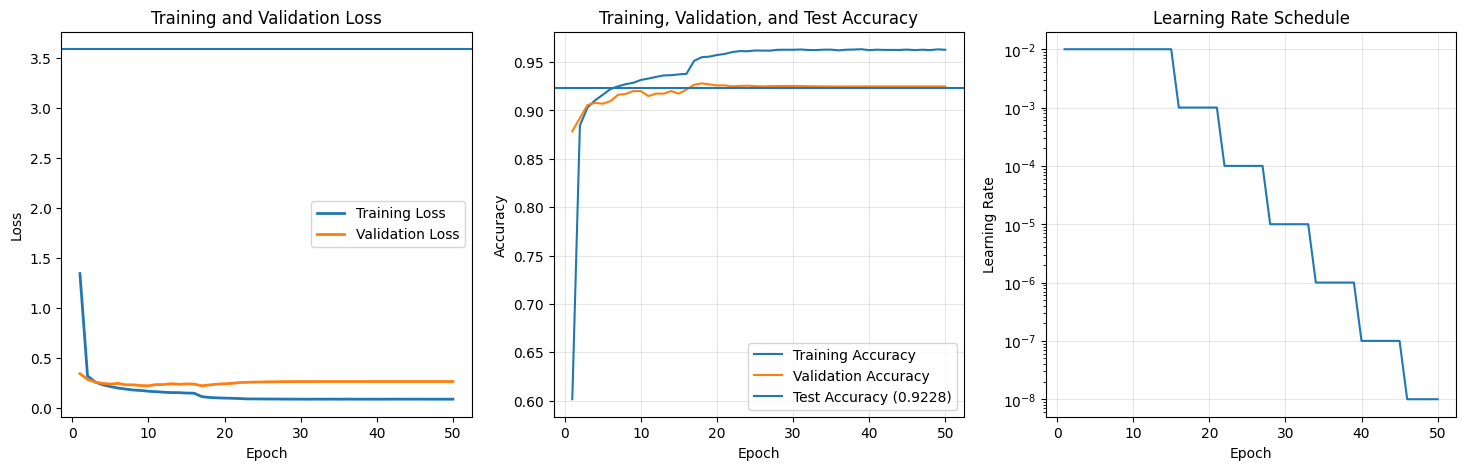

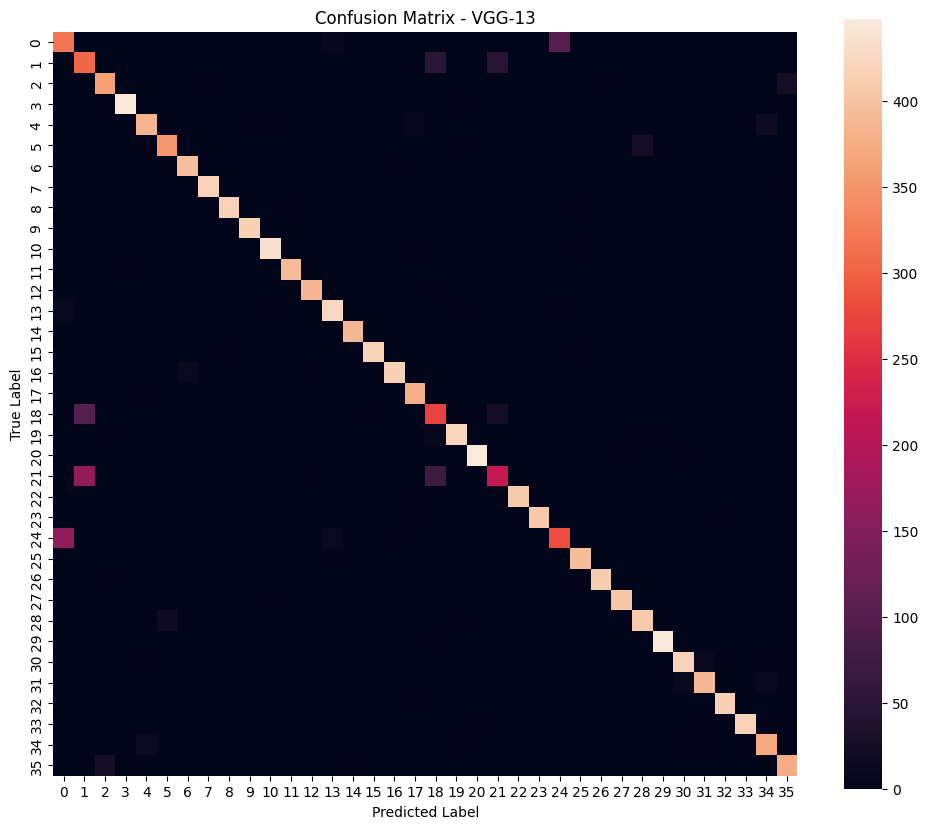

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(vgg_history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs, vgg_history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(epochs, vgg_history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].axhline(y=loss_fn(torch.zeros(1, len(full_dataset.classes)).to(device), 
                          torch.zeros(1, dtype=torch.long).to(device)).item())
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(epochs, vgg_history['train_acc'], label='Training Accuracy')
axes[1].plot(epochs, vgg_history['val_acc'], label='Validation Accuracy')
axes[1].axhline(y=test_acc, label=f'Test Accuracy ({test_acc:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training, Validation, and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate schedule
axes[2].plot(epochs, vgg_history['lr'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.show()

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, square=True)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - VGG-13')
plt.show()




In [11]:
torch.save(vgg13_model.state_dict(), "a2_part4_vgg13_weights_JadenPeacock.pkl")

# Save complete model info
model_info = {
    'model_state_dict': vgg13_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_acc,
    'num_classes': len(full_dataset.classes),
    'history': vgg_history
}
torch.save(model_info, "a2_part4_vgg13_model_JadenPeacock.pkl")


print("\nVGG-13 Model Summary:")
print(f"  Architecture: VGG-13 )")
print(f"  Parameters: {total_params:,}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Training Time: {sum(vgg_history['epoch_time']):.2f}s")
print(f"  Dropout: 0.5 ")
print(f"  LR Scheduler: ReduceLROnPlateau")


VGG-13 Model Summary:
  Architecture: VGG-13 )
  Parameters: 45,211,108
  Test Accuracy: 0.9228
  Training Time: 1625.05s
  Dropout: 0.5 
  LR Scheduler: ReduceLROnPlateau


References

https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

https://docs.nvidia.com/cuda/

https://arxiv.org/abs/1409.1556

https://thegrigorian.medium.com/understanding-vgg-neural-networks-architecture-and-implementation-400d99a9e9ba

https://www.kaggle.com/datasets/pytorch/vgg13bn